In [1]:
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import load_data
from src.task1.config import N_STATIONS, SPACE_LIMIT
from src.task1.vizualizator import plot_representation
from src.task1.evaluator import estimate_coverage, estimate_objective

In [2]:
data = load_data('data_1')

radii = data['tower_connection_radius'].values
centers = data[['center_x_coordinate', 'center_y_coordinate']].values

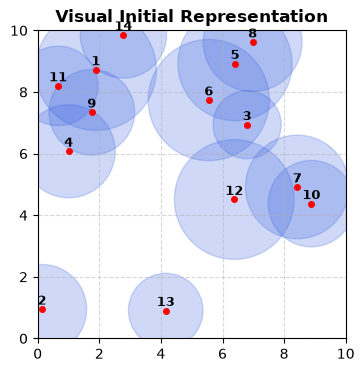

In [3]:
plot_representation(centers, radii, 'Visual Initial Representation')

In [5]:
estimate_coverage(centers, radii)

np.float64(0.582318)

In [6]:
def optimize_verlet(centers, radii, space_limit=10.0, iterations=200, dt=0.1, damping=0.93, radius_coef=0.9):

    pos = centers.copy()
    prev_pos = centers.copy()  # Швидкість неявно зберігається через різницю позицій
    best_coverage = estimate_coverage(centers, radii)
    
    for step in range(iterations):
        acc = np.zeros_like(pos)  # Вектор прискорень (сил) на цьому кроці
        
        # Обчислення взаємного відштовхування кіл
        for i in range(N_STATIONS):
            for j in range(N_STATIONS):
                if i == j:
                    continue
                
                delta = pos[i] - pos[j]
                dist = np.linalg.norm(delta)
                min_dist = radii[i] + radii[j]
                
                # Якщо кола перетинаються — виникає сила інтерференційного тиску
                if dist < min_dist:
                    if dist == 0:  # Запобігання діленню на нуль при збігу центрів
                        direction = np.array([np.cos(i), np.sin(i)])
                        overlap = min_dist
                    else:
                        direction = delta / dist
                        overlap = min_dist - dist
                    
                    # Сила відштовхування пропорційна глибині накладання кіл
                    acc[i] += direction * overlap * 2.5
        
        # Verlet calculation: x_new = x_curr + (x_curr - x_prev) * damping + a * dt^2
        current_pos = pos.copy()
        pos = current_pos + (current_pos - prev_pos) * damping + acc * (dt ** 2)
        prev_pos = current_pos
        
        # Boundary constraints
        for i in range(N_STATIONS):
            pos[i][0] = np.clip(pos[i][0], 0.0 + radius_coef * radii[i], space_limit - radius_coef * radii[i])
            pos[i][1] = np.clip(pos[i][1], 0.0 + radius_coef * radii[i], space_limit - radius_coef * radii[i])

        # Plot results
        plot_representation(pos, radii, f'Visual Representation {step + 1}')

        # Coverage estimation
        coverage = estimate_coverage(pos, radii)
        print(f'Iteration: {step + 1} Coverage: {coverage}')
        if coverage > best_coverage:
            best_coverage = coverage.copy()
            best_pos = pos.copy()

    return best_pos

In [ ]:
new_centers = optimize_verlet(centers, radii)

In [ ]:
estimate_coverage(new_centers, radii)

In [ ]:
from scipy.optimize import differential_evolution

In [ ]:
opt_results = differential_evolution(
    estimate_objective,
    args = (radii,),
    bounds = [(0, 10)] * (2 * N_STATIONS),
    strategy='best1bin',
    popsize=10,
    mutation=(0.5, 1.0),
    recombination=0.8,
    disp=True,
    maxiter=10,
    tol=1e-5,
    polish=False #True after test
)

In [7]:
def simulated_annealing(initial_pos, radii, space_limit=10.0, 
                        max_iter=2000, init_temp=1.0, cooling_rate=0.995):
    """
    Оптимізує координати БС методом імітації відпалу.
    """
    # Ініціалізація поточного стану
    current_pos = initial_pos.copy()
    current_score = estimate_coverage(current_pos, radii)
    
    # Змінні для збереження найкращого знайденого результату
    best_pos = current_pos.copy()
    best_score = current_score
    
    temp = init_temp
    history = [current_score]
    
    for i in range(max_iter):
        # 1. Генеруємо новий стан (робимо випадковий невеликий зсув)
        # Розмір кроку (радіус мутації) зменшується разом із температурою
        step_size = 0.5 * temp
        new_pos = current_pos.copy()
        
        # Обираємо ОДНУ випадкову станцію для зсуву (це ефективніше, ніж рухати всі одразу)
        idx = np.random.randint(0, N_STATIONS)
        new_pos[idx] += np.random.uniform(-step_size, step_size, size=2)
        
        # Обмеження Boundary Constraints (Центр строго всередині простору 10х10)
        new_pos[idx] = np.clip(new_pos[idx], 0.0, space_limit)
        
        # 2. Рахуємо покриття для нового стану
        new_score = estimate_coverage(current_pos, radii)
        
        # 3. Приймаємо або відхиляємо новий стан
        delta = new_score - current_score
        
        if delta > 0:
            # Якщо покриття покращилося — завжди приймаємо
            current_pos = new_pos.copy()
            current_score = new_score
            
            # Оновлюємо глобально найкращий результат
            if new_score > best_score:
                best_score = new_score
                best_pos = new_pos.copy()
        else:
            # Якщо покриття погіршилося — приймаємо з певною ймовірністю Больцмана
            acceptance_probability = np.exp(delta / (temp + 1e-8))
            if np.random.uniform(0, 1) < acceptance_probability:
                current_pos = new_pos.copy()
                current_score = new_score
        
        # 4. Знижуємо температуру (охолодження системи)
        temp *= cooling_rate
        history.append(best_score)
        
        # Логування прогресу
        if (i + 1) % 400 == 0:
            print(f"Ітерація {i+1}/{max_iter} | Поточне найкраще покриття: {best_score*100:.2f}% | Temp: {temp:.4f}")
            
    return best_pos, best_score, history

In [8]:
from time import perf_counter

In [9]:
start = perf_counter()

best_centers, best_coverage, run_history = simulated_annealing(
    centers, radii, max_iter=2500, init_temp=1.0, cooling_rate=0.996
)

elapsed = perf_counter() - start
print(f"Execution time: {elapsed:.6f} s")

Ітерація 400/2500 | Поточне найкраще покриття: 59.61% | Temp: 0.2012
Ітерація 800/2500 | Поточне найкраще покриття: 59.61% | Temp: 0.0405
Ітерація 1200/2500 | Поточне найкраще покриття: 59.61% | Temp: 0.0082
Ітерація 1600/2500 | Поточне найкраще покриття: 59.61% | Temp: 0.0016
Ітерація 2000/2500 | Поточне найкраще покриття: 59.61% | Temp: 0.0003
Ітерація 2400/2500 | Поточне найкраще покриття: 59.61% | Temp: 0.0001
Execution time: 711.710663 s


In [13]:
class SimulatedAnnealing:
    def __init__(
        self,
        objective,
        bounds,
        max_iter=5000,
        initial_temp=1.0,
        cooling_rate=0.995,
        step_size=0.3,
        seed=None,
    ):
        self.objective = objective
        self.bounds = np.asarray(bounds)

        self.lower = self.bounds[:, 0]
        self.upper = self.bounds[:, 1]

        self.max_iter = max_iter
        self.initial_temp = initial_temp
        self.cooling_rate = cooling_rate
        self.step_size = step_size

        self.rng = np.random.default_rng(seed)

    def optimize(self, *args):

        current = self.rng.uniform(self.lower, self.upper)
        current_score = self.objective(current, *args)

        best = current.copy()
        best_score = current_score

        T = self.initial_temp

        history = []

        for iteration in range(self.max_iter):

            # ---------- Generate neighbour ----------

            candidate = current.copy()

            perturbation = self.rng.normal(
                0,
                self.step_size,
                size=len(candidate)
            )

            candidate += perturbation

            candidate = np.clip(
                candidate,
                self.lower,
                self.upper
            )

            candidate_score = self.objective(candidate, *args)

            delta = candidate_score - current_score

            # ---------- Acceptance ----------

            if delta < 0:

                accept = True

            else:

                probability = np.exp(-delta / T)

                accept = self.rng.random() < probability

            if accept:

                current = candidate
                current_score = candidate_score

            if current_score < best_score:

                best = current.copy()
                best_score = current_score

            history.append(best_score)

            T *= self.cooling_rate

            if iteration % 500 == 0:

                print(
                    f"{iteration:5d}"
                    f"  score={-best_score:.5f}"
                    f"  T={T:.5f}"
                )

        return best, best_score, history

In [ ]:
bounds = [(0, 10)] * (2 * N_STATIONS)

sa = SimulatedAnnealing(
    objective=estimate_objective,
    bounds=bounds,
    max_iter=10000,
    initial_temp=1.0,
    cooling_rate=0.999,
    step_size=0.25,
    seed=42,
)

best_solution, best_score, history = sa.optimize(radii)

best_centers = best_solution.reshape(-1, 2)

print("Coverage =", -best_score)

    0  score=0.65155  T=0.99900
  500  score=0.74411  T=0.60577
 1000  score=0.74411  T=0.36733
 1500  score=0.74411  T=0.22274
 2000  score=0.80432  T=0.13506
 2500  score=0.80432  T=0.08190
 3000  score=0.80432  T=0.04966
 3500  score=0.81063  T=0.03011
